<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Trabajo%20Integrador/trabajo_integrador_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder y clasificador convolucional sobre Fashion-MNIST

## Preliminares
Instalamos e importamos todas las librerias necesarias

In [ ]:
!pip3 install torch torchvision torchaudio torchviz

In [ ]:
import os
import pickle
import datetime
from collections import defaultdict

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json

In [ ]:
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd

In [ ]:
import google.colab
from google.colab import files

In [ ]:
import copy

Elegimos para usar la GPU o, si no está disponible, la CPU

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## Base de datos

Vamos a cargar el dataset y ver cómo están las imágenes

In [ ]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])

# Download and load the training data
# acá instalamos todo. train es para entrenar y valid para validar
train_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

In [ ]:
# veamos cuantas imagenes hay
len(train_set_orig),len(valid_set_orig)

(60000, 10000)

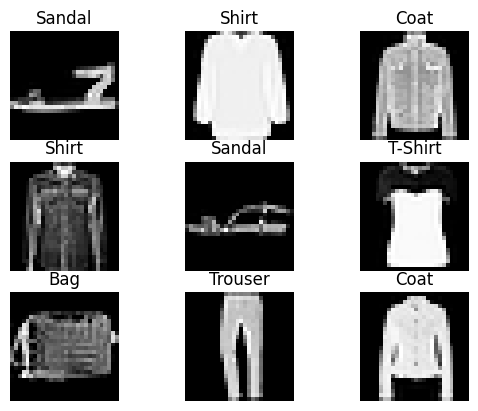

In [ ]:
labels_names = {
    0: "T-Shirt",    # Remera manga corta
    1: "Trouser",    # Pantalon
    2: "Pullover",   # Buzo
    3: "Dress",      # Vestido
    4: "Coat",       # Abrigo
    5: "Sandal",     # Sandalia
    6: "Shirt",      # Remera manga larga
    7: "Sneaker",    # Zapatilla
    8: "Bag",        # Bolso
    9: "Ankle Boot", # Bota
}

figure = plt.figure()
cols,rows = 3,3
for i in range(1,cols*rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # Los números aleatorios tambien se pueden generar desde pytorch. Util para trabajar en la GPU.
    # eligiendo el j así estamos viendo 9 imagenes al azar del conjunto, o sea, pueden repetirse el tipo
    image,label = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    plt.title(labels_names[label])
    plt.axis("off")
    plt.imshow(image.squeeze(),cmap="Greys_r")
plt.show()

In [ ]:
# creamos un dataset personalizado

In [ ]:
# Creamos una subclase de Dataset que nos sirva para muestrear imagenes en el entrenamiento del autoencoder
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset=dataset
    # Redefinimos el método .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefinimos el método .__getitem__()
    def __getitem__(self,i):
        image,label=self.dataset[i]
        input  = image
        #output = torch.flatten(image) # Reescribimos el label original con una version achatada de la imagen.
        output = image
        return input,output

In [ ]:
# Convertimos FashionMNIST Dataset a CustomDataset
train_set = CustomDataset(train_set_orig)
valid_set = CustomDataset(valid_set_orig)

## Red neuronal auto-encoder convolucional de varias capas

Definamos la red neuronal

In [ ]:
class AutoEncoderConv(nn.Module):
    def __init__(self,n=64,p=0.2): #  inicializa los atributos del objeto que creamos
        super(AutoEncoderConv, self).__init__()

        self.flatten = nn.Flatten() # "capa" flatten, achata el array

        # defino el encoder como secuencia
        self.encoder = nn.Sequential(
            # 1era capa conv2d
            nn.Conv2d(1, 16, kernel_size=(3, 3)), # de 1 canal a 16, con kernel (3, 3). (1, 28, 28)==>(16, 26, 26). Se pierden 2 por la primera y ultima fila y primera y ultima columna.
            nn.ReLU(),
            nn.Dropout(p),
            nn.MaxPool2d(2, 2), # a cada canal lo reduce a la mitad. (16, 26, 26)==>(16, 13, 13)
            # 2da capa conv2d
            nn.Conv2d(16, 32, kernel_size=(3, 3)), # (16, 13, 13)==>(32, 11, 11)
            nn.ReLU(),
            nn.Dropout(p),
            nn.MaxPool2d(2, 2), # (32, 11, 11)==>(32, 5, 5)
            # capa lineal
            nn.Flatten(), # un vector de 32*5*5
            nn.Linear(32*5*5,n), # mapea un vector de 32*5*5 con uno de n (de la capa del medio)
            nn.ReLU(),
            nn.Dropout(p),
        )

        # defino el decoder
        self.decoder = nn.Sequential(
            # capa lineal
            nn.Linear(n,32*5*5),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Unflatten(1, (32, 5, 5)), # de 1 a 32 de 5x5
            # capa conv2d transpuesta
            nn.ConvTranspose2d(32, 16, kernel_size=(4,4), stride=(2,2), output_padding=(1,1)), # (32, 5, 5) => (16, 13, 13). Es lo opuesto de conv2d y maxpool juntos, el kernel se mueve de a 2 (stride)
            nn.ReLU(),
            nn.Dropout(p),
            # otra capa conv2d transpuesta
            nn.ConvTranspose2d(16, 1, kernel_size=(3,3), stride=(2,2), output_padding=(1,1)), # (16, 13, 13) => (1, 28, 28)
            nn.Sigmoid(),
            #nn.Dropout(p), #va?

        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
n = 64
model_autoencoder = AutoEncoderConv(n) # uso 64 neuronas en la capa intermedia

In [ ]:
def batch(x):
  return x.unsqueeze(0) # (28,28)=>(1,28,28)

def unbatch(x):
  return x.squeeze().detach().cpu().numpy() # (1, 28, 28)=>(28, 28)

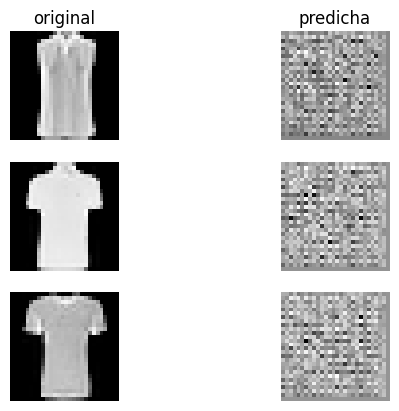

In [ ]:
# Miramos que imagenes predice el modelo sin entrenar
figure = plt.figure()
rows,cols = 3,2
i = 0 # subplot index
for row in range(1,rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # elegimos un elemento random de el conjunto de entrenamiento
    # Ploteamos la imagen original
    i += 1
    image,flatten_imagen = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    if row==1: # le ponemos titulo solo a la primera imagen
      plt.title("original")
    plt.axis("off")
    plt.imshow(unbatch(image),cmap="Greys_r") # plotemaos la original
    # Ploteamos la imagen predicha
    i += 1
    figure.add_subplot(rows,cols,i)
    if row==1:
      plt.title("predicha")
    plt.axis("off")
    image_pred = unbatch(model_autoencoder(batch(image)))
    plt.imshow(image_pred,cmap="Greys_r")
plt.show()

## Entrenando el autoencoder

Esto se hace para entrenar el codificador. Si o si necesito decodificar para que el codificador se entrene.

In [ ]:
batch_size = 1000
train_loader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size,shuffle=True)

In [ ]:
# Definimos la función de entrenamiento (loop de entrenamiento)
def train_loop(dataloader,model,loss_fn,optimizer): # le pasamos un cargador de datos, un modelo, una funcion de perdida (en este caso cross entropy) y optimizador
    # Activamos la maquinaria de entrenamiento del modelo. para calcular los gradientes
    model.train()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss = 0
    # Iteramos sobre lotes (batchs)
    for batch, (X, y) in enumerate(dataloader):
        # Copiamos las entradas y las salidas al dispositivo de trabajo
        X = X.to(device)
        y = y.to(device)
        # Calculamos la predicción del modelo y la correspondiente pérdida (error)
        pred = model(X)
        loss = loss_fn(pred,y)
        # Backpropagamos usando el optimizador proveido.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Imprimimos el progreso...
        loss_value = loss.item()
        sum_loss += loss_value
        if batch*batch_size % 10000 == 0:
            current = batch*len(X)
            print(f"@train_loop batch={batch:>5d} loss={loss_value:>7f}  muestras-procesadas=[{current:>5d}/{size:>5d}]")
    avg_loss = sum_loss/num_batches # el error total va a ser el promedio de los errores
    return avg_loss

# De manera similar, definimos la función de validación
def valid_loop(dataloader,model,loss_fn):
    # Desactivamos la maquinaria de entrenamiento del modelo
    model.eval()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss = 0
    # Para testear, desactivamos el cálculo de gradientes.
    with torch.no_grad():
        # Iteramos sobre lotes (batches)
        for X,y in dataloader:
            # Copiamos las entradas y las salidas al dispositivo de trabajo
            X = X.to(device)
            y = y.to(device)
            # Calculamos las predicciones del modelo...
            pred = model(X)
            # y las correspondientes pérdidas (errores), los cuales vamos acumulando en un valor total.
            sum_loss += loss_fn(pred,y).item()
    # Calculamos la pérdida total y la fracción de clasificaciones correctas, y las imprimimos.
    avg_loss = sum_loss/num_batches
    print(f"@valid_loop avg_loss={avg_loss:>8f}")
    return avg_loss

In [ ]:
# Creamos una instancia de una función de pérdida, error cuadratico medio en este caso
loss_fn = nn.MSELoss() # Para autoencoder

In [ ]:
n = 64
model_autoencoder = AutoEncoderConv(n)

In [ ]:
# Creamos un optimizador ADAM
learning_rate = 1e-3 # necesario para definir
optimizer = torch.optim.Adam(model_autoencoder.parameters(),lr=learning_rate,eps=1e-08,weight_decay=0,amsgrad=False)

In [ ]:
# Determinamos en que dispositivo vamos a trabajar, una CPU o una GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Pasamos el modelo al dispositivo
model_autoencoder = model_autoencoder.to(device)

In [ ]:
# Finalmente, entrenamos iterando sobre épocas.
# Además, testeamos el modelo en cada una de ellas.
num_epochs = 30
list_train_avg_loss_incorrecta = []
list_train_avg_loss = []
list_valid_avg_loss = []
for epoch in range(num_epochs):
    print(" ")
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_avg_loss_incorrecta = train_loop(train_loader,model_autoencoder,loss_fn,optimizer) #entrenamos
    # el de arriba es el incorrecto pq te tira el error a medida que va entrenando (el error cometido en el 1er ejemplo es mucho mas grande que en
    # el último). una vez que deja de entrenar, debemos validar los datos de entrenamiento para tener la curva que se compara
    train_avg_loss = valid_loop(train_loader,model_autoencoder,loss_fn) # ahora validamos los datos de entrenamiento
    valid_avg_loss = valid_loop(valid_loader,model_autoencoder,loss_fn) # validamos los de validación

    #armo listas
    list_train_avg_loss_incorrecta.append(train_avg_loss_incorrecta)
    list_train_avg_loss.append(train_avg_loss)
    list_valid_avg_loss.append(valid_avg_loss)
print("Done!")

 
Epoch 1
-------------------------------
@train_loop batch=    0 loss=0.143585  muestras-procesadas=[    0/60000]
@train_loop batch=   10 loss=0.140337  muestras-procesadas=[10000/60000]
@train_loop batch=   20 loss=0.126536  muestras-procesadas=[20000/60000]
@train_loop batch=   30 loss=0.107672  muestras-procesadas=[30000/60000]
@train_loop batch=   40 loss=0.089965  muestras-procesadas=[40000/60000]
@train_loop batch=   50 loss=0.080097  muestras-procesadas=[50000/60000]
@valid_loop avg_loss=0.070996
@valid_loop avg_loss=0.070724
 
Epoch 2
-------------------------------
@train_loop batch=    0 loss=0.073581  muestras-procesadas=[    0/60000]
@train_loop batch=   10 loss=0.070392  muestras-procesadas=[10000/60000]
@train_loop batch=   20 loss=0.067998  muestras-procesadas=[20000/60000]
@train_loop batch=   30 loss=0.065218  muestras-procesadas=[30000/60000]
@train_loop batch=   40 loss=0.063466  muestras-procesadas=[40000/60000]
@train_loop batch=   50 loss=0.061079  muestras-proce

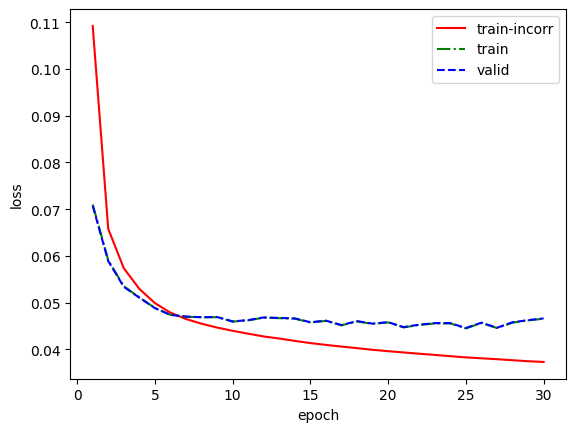

In [ ]:
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss_incorrecta)+1),list_train_avg_loss_incorrecta,label="train-incorr",linestyle='-',c='red')
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

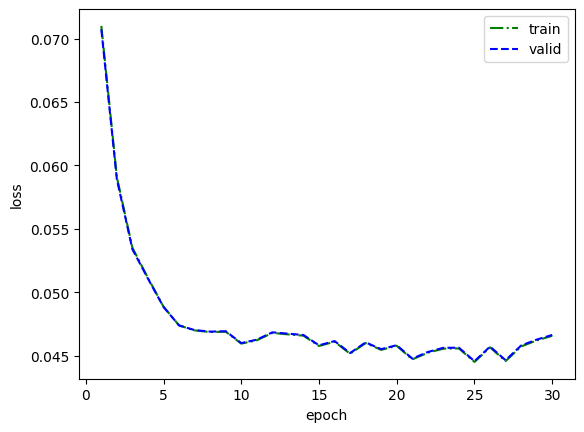

In [ ]:
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

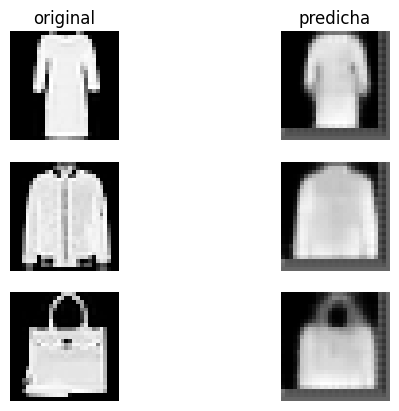

In [ ]:
# Miramos que imagenes predice el modelo sin entrenar
figure = plt.figure()
rows,cols = 3,2
i = 0 # subplot index
for row in range(1,rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # elegimos un elemento random de el conjunto de entrenamiento
    # Ploteamos la imagen original
    i += 1
    image,flatten_imagen = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    if row==1: # le ponemos titulo solo a la primera imagen
      plt.title("original")
    plt.axis("off")
    plt.imshow(unbatch(image),cmap="Greys_r") # plotemaos la original
    # Ploteamos la imagen predicha
    i += 1
    figure.add_subplot(rows,cols,i)
    if row==1:
      plt.title("predicha")
    plt.axis("off")
    image_pred = unbatch(model_autoencoder(batch(image)))
    plt.imshow(image_pred,cmap="Greys_r")
plt.show()

## Definiendo y entrenando un clasificador convolucional reutilizando el encoder

Definamos la red neuronal

In [ ]:
class ClasificadorConv(nn.Module):
    def __init__(self, autoencoder_conv=None, copy_encoder=True, n=64,p=0.2): #  inicializa los atributos del objeto que creamos
        super().__init__()

        # si no entregamos ningun autoencoder, entonces hacemos un encoder de nuevo
        if autoencoder_conv is None:
            self.encoder = nn.Sequential(
              # 1era capa conv2d
              nn.Conv2d(1, 16, kernel_size=(3, 3)), # de 1 canal a 16, con kernel (3, 3). (1, 28, 28)==>(16, 26, 26). Se pierden 2 por la primera y ultima fila y primera y ultima columna.
              nn.ReLU(),
              nn.Dropout(p),
              nn.MaxPool2d(2, 2), # a cada canal lo reduce a la mitad. (16, 26, 26)==>(16, 13, 13)
              # 2da capa conv2d
              nn.Conv2d(16, 32, kernel_size=(3, 3)), # (16, 13, 13)==>(32, 11, 11)
              nn.ReLU(),
              nn.Dropout(p),
              nn.MaxPool2d(2, 2), # (32, 11, 11)==>(32, 5, 5)
              # capa lineal
              nn.Flatten(), # un vector de 32*5*5
              nn.Linear(32*5*5,n), # mapea un vector de 32*5*5 con uno de n (de la capa del medio)
              nn.ReLU(),
              nn.Dropout(p),
            )
        else:
          # si damos un autoencoder, entonces vamos a copiarlo
          if copy_encoder:
            print("Copiando el encoder anterior...")
            self.encoder = copy.deepcopy(autoencoder_conv.encoder)
          else:
            # o lo copiamos o lo usamos y lo modificamos, es mejor copiarlo
            print("Usando el encoder anterior...")
            self.encoder = autoencoder_conv.encoder

        # ahora hacemos el clasificador
        self.clasificador = nn.Sequential(
            nn.Linear(n, 10),
            nn.ReLU(),
            #nn.Sigmoid(),
            nn.Dropout(p), #va?
        )


    def forward(self, x):
        x = self.encoder(x)
        x = self.clasificador(x)
        return x

Ahora entrenemos el clasificador

In [ ]:
train_set = train_set_orig
valid_set = valid_set_orig

In [ ]:
batch_size = 100
train_loader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size,shuffle=True)

In [ ]:
# Definimos la función de entrenamiento (loop de entrenamiento)
# ahora agregamos la precision
def train_loop(dataloader,model,loss_fn,optimizer): # le pasamos un cargador de datos, un modelo, una funcion de perdida (en este caso cross entropy) y optimizador
    # Activamos la maquinaria de entrenamiento del modelo. para calcular los gradientes
    model.train()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss, sum_correct = 0, 0
    # Iteramos sobre lotes (batchs)
    for batch, (X, y) in enumerate(dataloader):
        # Copiamos las entradas y las salidas al dispositivo de trabajo
        X = X.to(device)
        y = y.to(device)
        # Calculamos la predicción del modelo y la correspondiente pérdida (error)
        pred = model(X)
        loss = loss_fn(pred,y)
        # Backpropagamos usando el optimizador proveido.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Imprimimos el progreso...
        loss_value = loss.item()
        sum_loss += loss_value
        # También calculamos el número de predicciones correctas, y lo acumulamos en un total.
        sum_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        if batch*batch_size % 10000 == 0:
            current = batch*len(X)
            print(f"@train_loop batch={batch:>5d} loss={loss_value:>7f}  muestras-procesadas=[{current:>5d}/{size:>5d}]")
    avg_loss = sum_loss/num_batches # el error total va a ser el promedio de los errores
    precision = sum_correct/size # la precision va a ser la cantidad de veces que acertó dividido la cantidad total de predicciones
    return avg_loss,precision

# De manera similar, definimos la función de validación
def valid_loop(dataloader,model,loss_fn):
    # Desactivamos la maquinaria de entrenamiento del modelo
    model.eval()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss,sum_correct = 0,0
    # Para testear, desactivamos el cálculo de gradientes.
    with torch.no_grad():
        # Iteramos sobre lotes (batches)
        for X,y in dataloader:
            # Copiamos las entradas y las salidas al dispositivo de trabajo
            X = X.to(device)
            y = y.to(device)
            # Calculamos las predicciones del modelo...
            pred = model(X)
            # y las correspondientes pérdidas (errores), los cuales vamos acumulando en un valor total.
            sum_loss += loss_fn(pred,y).item()
            # También calculamos el número de predicciones correctas, y lo acumulamos en un total.
            sum_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    # Calculamos la pérdida total y la fracción de clasificaciones correctas, y las imprimimos.
    avg_loss = sum_loss/num_batches
    precision = sum_correct/size
    print(f"@valid_loop avg_loss={avg_loss:>8f}")
    return avg_loss,precision

In [ ]:
# Creamos una instancia de una función de pérdida, crossentropy en este caso
loss_fn = nn.CrossEntropyLoss()

In [ ]:
model_clasificador = ClasificadorConv(autoencoder_conv=model_autoencoder) #model_autoencoder

Copiando el encoder anterior...


In [ ]:
# Creamos un optimizador ADAM
learning_rate = 1e-3 # necesario para definir
#optimizer = torch.optim.Adam(model_clasificador.clasificador.parameters(),lr=learning_rate,eps=1e-08,weight_decay=0,amsgrad=False) #model_clasificador.clasificador?
optimizer = torch.optim.Adam(model_clasificador.parameters(),lr=learning_rate,eps=1e-08,weight_decay=0,amsgrad=False) #model_clasificador.clasificador?

In [ ]:
# Determinamos en que dispositivo vamos a trabajar, una CPU o una GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Pasamos el modelo al dispositivo
model_clasificador = model_clasificador.to(device)

In [ ]:
# Finalmente, entrenamos iterando sobre épocas.
# Además, testeamos el modelo en cada una de ellas.
num_epochs = 30
list_train_avg_loss_incorrecta = []
list_train_avg_loss = []
list_valid_avg_loss = []
list_train_precision_incorrecta = []
list_train_precision = []
list_valid_precision = []
for epoch in range(num_epochs):
    print(" ")
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_avg_loss_incorrecta,train_precision_incorrecta = train_loop(train_loader,model_clasificador,loss_fn,optimizer) #entrenamos
    # el de arriba es el incorrecto pq te tira el error a medida que va entrenando (el error cometido en el 1er ejemplo es mucho mas grande que en
    # el último). una vez que deja de entrenar, debemos validar los datos de entrenamiento para tener la curva que se compara
    train_avg_loss,train_precision = valid_loop(train_loader,model_clasificador,loss_fn) # ahora validamos los datos de entrenamiento
    valid_avg_loss,valid_precision = valid_loop(valid_loader,model_clasificador,loss_fn) # validamos los de validación

    #armo listas
    list_train_avg_loss_incorrecta.append(train_avg_loss_incorrecta)
    list_train_avg_loss.append(train_avg_loss)
    list_valid_avg_loss.append(valid_avg_loss)
    list_train_precision_incorrecta.append(train_precision_incorrecta)
    list_train_precision.append(train_precision)
    list_valid_precision.append(valid_precision)
print("Done!")

 
Epoch 1
-------------------------------
@train_loop batch=    0 loss=4.241848  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=1.687784  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=1.375459  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=1.279899  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=1.340660  muestras-procesadas=[40000/60000]
@train_loop batch=  500 loss=1.043356  muestras-procesadas=[50000/60000]
@valid_loop avg_loss=0.894339
@valid_loop avg_loss=0.910566
 
Epoch 2
-------------------------------
@train_loop batch=    0 loss=1.200807  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=1.142906  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=1.017579  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=0.759521  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=0.890931  muestras-procesadas=[40000/60000]
@train_loop batch=  500 loss=1.163998  muestras-proce

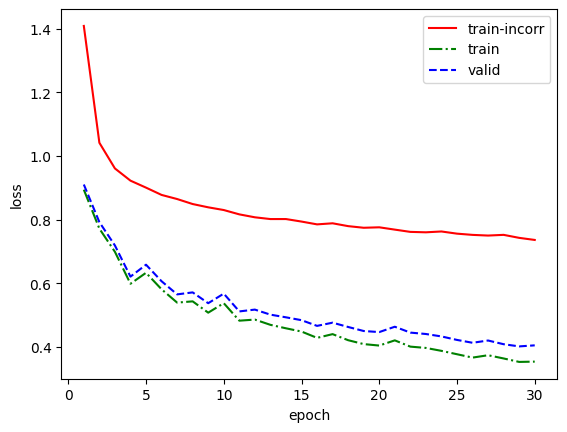

In [ ]:
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss_incorrecta)+1),list_train_avg_loss_incorrecta,label="train-incorr",linestyle='-',c='red')
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

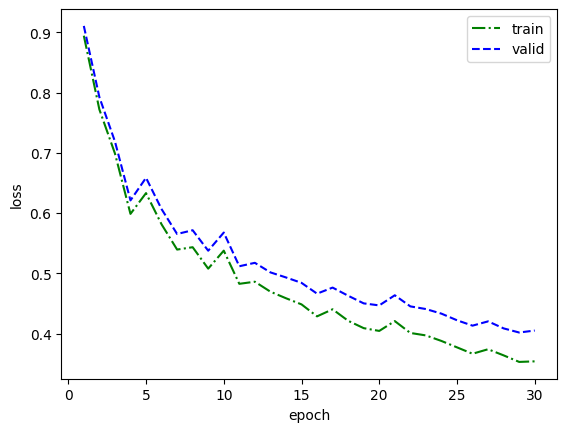

In [ ]:
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

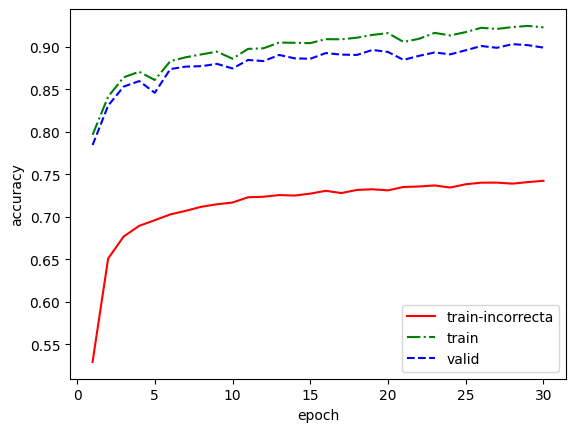

In [ ]:
plt.xlabel('epoch')
plt.ylabel('accuracy')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_precision_incorrecta)+1),list_train_precision_incorrecta,label="train-incorrecta",linestyle='-',c='red')
plt.plot(range(1,len(list_train_precision)+1),list_train_precision,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_precision)+1),list_valid_precision,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

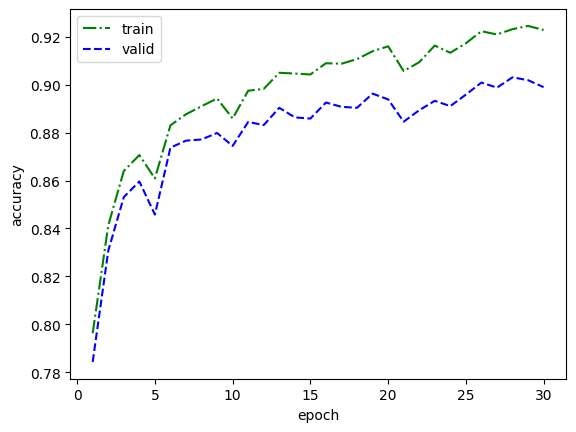

In [ ]:
plt.xlabel('epoch')
plt.ylabel('accuracy')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_precision)+1),list_train_precision,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_precision)+1),list_valid_precision,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

## Observemos las predicciones

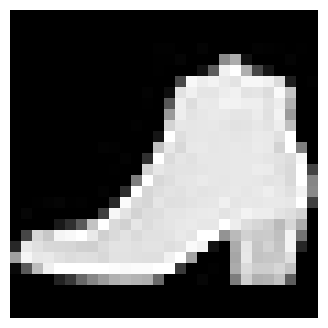

El objeto predicho con mayor probabilidad es Pullover
y la probabilidad de cada uno: 
 
Etiqueta correcta: Ankle Boot
----------------
Etiqueta     Probabilidad
Pullover     0.96233
Ankle Boot   0.00419
Bag          0.00419
Sneaker      0.00419
Shirt        0.00419
Sandal       0.00419
Coat         0.00419
Dress        0.00419
Trouser      0.00419
T-Shirt      0.00419


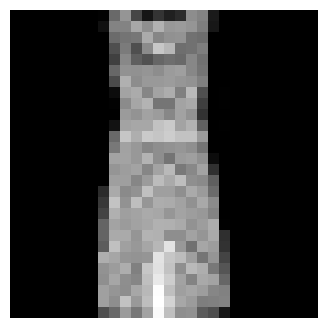

El objeto predicho con mayor probabilidad es Trouser
y la probabilidad de cada uno: 
 
Etiqueta correcta: Dress
----------------
Etiqueta     Probabilidad
Trouser      0.99999
Ankle Boot   0.00000
Bag          0.00000
Sneaker      0.00000
Shirt        0.00000
Sandal       0.00000
Coat         0.00000
Dress        0.00000
Pullover     0.00000
T-Shirt      0.00000


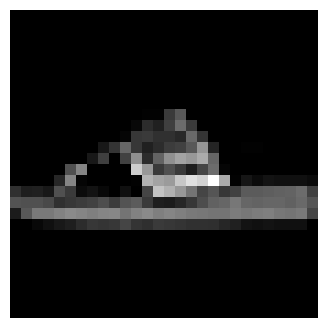

El objeto predicho con mayor probabilidad es Trouser
y la probabilidad de cada uno: 
 
Etiqueta correcta: Sandal
----------------
Etiqueta     Probabilidad
Trouser      1.00000
Ankle Boot   0.00000
Bag          0.00000
Sneaker      0.00000
Shirt        0.00000
Sandal       0.00000
Coat         0.00000
Dress        0.00000
Pullover     0.00000
T-Shirt      0.00000


In [ ]:
ejemplos = 3
for ejemplo in range(1,ejemplos+1):
    """
    Grafica un ejemplo del conjunto de entrenamiento
    """
    figure = plt.figure(figsize=(4, 4))
    j = torch.randint(len(valid_set_orig),size=(1,)).item() # elegimos un elemento random de el conjunto de entrenamiento
    img, label = valid_set_orig[j]

    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
    plt.show()


    """
    Muestra la predicción para el ejemplo
    """
    model_clasificador.eval()
    x, y = valid_set_orig[ejemplo][0], valid_set_orig[ejemplo][1] # imagen y
    with torch.no_grad():
        pred = model_clasificador(x.unsqueeze(1).to(device)) #le doy la imagen al clasificador
    sorted = pred.sort() # creo que los ordena en orden ascendente
    values = softmax(sorted.values[0], dim=-1) # no se muy bien que hace
    indices = sorted.indices[0]
    label_max = labels_names[indices[9].item()]
    print("El objeto predicho con mayor probabilidad es", label_max)
    print("y la probabilidad de cada uno: ")
    print(" ")
    print(
        f'Etiqueta correcta: {labels_names[label]}',
        end='\n----------------\n'
    )
    print('Etiqueta     Probabilidad')
    for v, idx in list(zip(values,indices))[::-1]:
        label_pred = labels_names[idx.item()]
        print(f'{label_pred:13}{v.item():.5f}')

## Hagamos la matriz de confusión

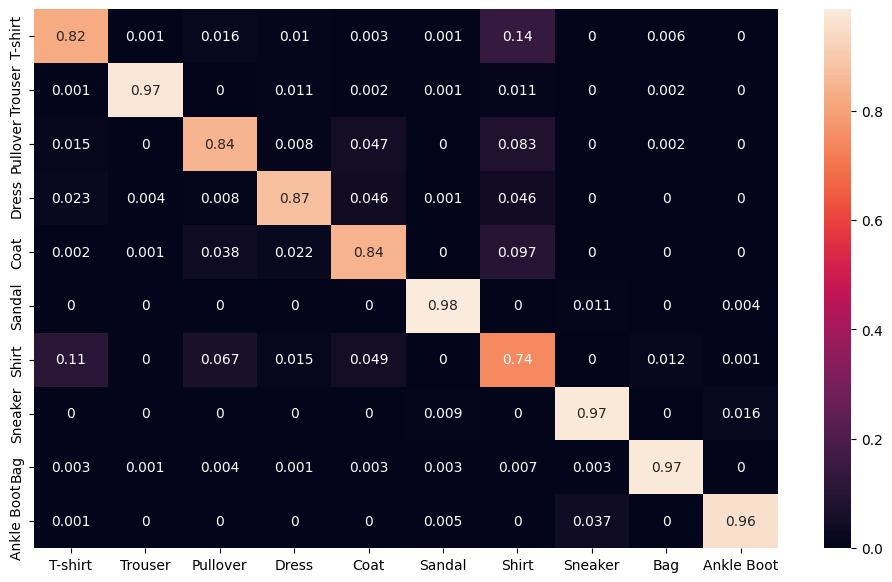

In [ ]:
y_pred = []
y_true = []

i = 0
for inputs, labels in valid_set_orig:

    model_clasificador.eval()
    x, y = valid_set_orig[i][0], valid_set_orig[i][1] # imagen y
    with torch.no_grad():
        pred = model_clasificador(x.unsqueeze(1).to(device)) #le doy la imagen al clasificador
    sorted = pred.sort() # creo que los ordena en orden ascendente
    values = softmax(sorted.values[0], dim=-1)
    indices = sorted.indices[0]

    label_max = indices[9].item()

    y_pred.append(label_max)
    y_true.append(labels)

    i = i+1


# constant for classes
classes = ('T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

# Build confusion matrix
cf_matrix = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cf_matrix / np.sum(cf_matrix, axis=1)[:, None], index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')